In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import warnings
warnings.filterwarnings('ignore')

In [1]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 인위적인 데이터셋을 만듭니다
x, y = make_blobs(random_state=0)
# 데이터와 타깃 레이블을 훈련 세트와 테스트 세트로 나눕니다
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
# 모델 객체를 만들고 훈련 세트로 학습시킵니다
logreg = LogisticRegression().fit(x_train, y_train)
# 모델을 테스트 세트로 평가합니다
print('test set score: {:.2f}'.format(logreg.score(x_test, y_test)))

test set score: 0.88


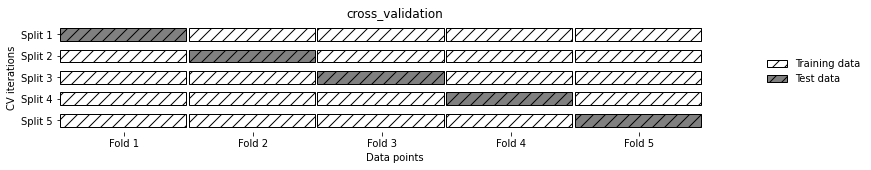

In [3]:
mglearn.plots.plot_cross_validation()

In [4]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

scores = cross_val_score(logreg, iris.data, iris.target)
print('cross validation score:', scores)

cross validation score: [0.96666667 1.         0.93333333 0.96666667 1.        ]


In [5]:
print('cross validation mean score: {:.2f}'.format(scores.mean()))

cross validation mean score: 0.97


In [6]:
from sklearn.model_selection import cross_validate
res = cross_validate(logreg, iris.data, iris.target, return_train_score=True)
res

{'fit_time': array([0.01754618, 0.02445292, 0.0081594 , 0.01115155, 0.01809907]),
 'score_time': array([0., 0., 0., 0., 0.]),
 'test_score': array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ]),
 'train_score': array([0.96666667, 0.96666667, 0.98333333, 0.98333333, 0.975     ])}

In [8]:
res_df = pd.DataFrame(res)
print(res_df)
print('mean time & score:\n', res_df.mean())

   fit_time  score_time  test_score  train_score
0  0.017546         0.0    0.966667     0.966667
1  0.024453         0.0    1.000000     0.966667
2  0.008159         0.0    0.933333     0.983333
3  0.011152         0.0    0.966667     0.983333
4  0.018099         0.0    1.000000     0.975000
mean time & score:
 fit_time       0.015882
score_time     0.000000
test_score     0.973333
train_score    0.975000
dtype: float64


In [9]:
from sklearn.datasets import load_iris
iris = load_iris()
print('iris label:\n', iris.target)

iris label:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


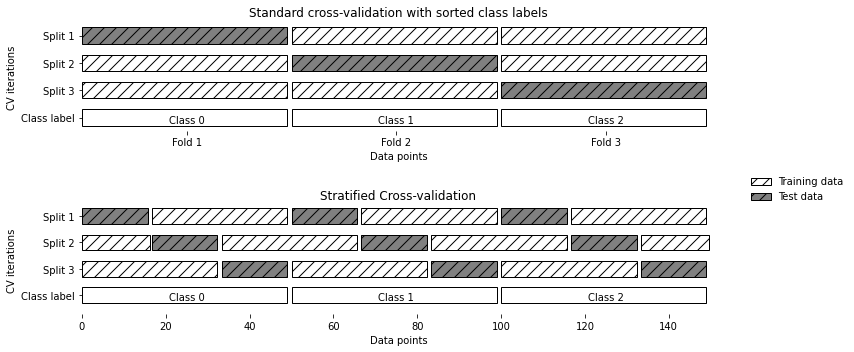

In [10]:
mglearn.plots.plot_stratified_cross_validation()

In [11]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=5)

In [12]:
print('cross validation score: \n', cross_val_score(logreg, iris.data, iris.target, cv=kfold))

cross validation score: 
 [1.         1.         0.86666667 0.93333333 0.83333333]


In [13]:
kfold = KFold(n_splits=3)
print('cross validation score: \n', cross_val_score(logreg, iris.data, iris.target, cv=kfold))

cross validation score: 
 [0. 0. 0.]


In [14]:
kfold = KFold(n_splits=3, shuffle=True, random_state=0)
print('cross validation score: \n', cross_val_score(logreg, iris.data, iris.target, cv=kfold))

cross validation score: 
 [0.98 0.96 0.96]


In [15]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)
print('cross validation split count:', len(scores))
print('mean accuracy: {:.2f}'.format(scores.mean()))

cross validation split count: 150
mean accuracy: 0.97


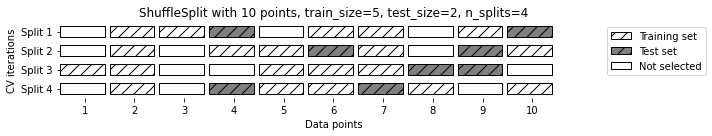

In [18]:
mglearn.plots.plot_shuffle_split()

In [19]:
from sklearn.model_selection import ShuffleSplit
shuffle_split = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10)
scores = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)
print('cross validation score:\n', scores)

cross validation score:
 [0.98666667 0.96       0.97333333 0.93333333 0.98666667 0.94666667
 0.98666667 0.94666667 0.94666667 0.96      ]


In [20]:
from sklearn.model_selection import GroupKFold
# 인위적 데이터셋 생성
x, y = make_blobs(n_samples=12, random_state=0)
# 처음 세 개의 샘플은 같은 그룹에 속하고, 다음은 네 개의 샘플이 같습니다
groups = [0,0,0,1,1,1,1,2,2,3,3,3]
scores = cross_val_score(logreg, x, y, groups=groups, cv=GroupKFold(n_splits=3))
print('cross validation score:\n', scores)

cross validation score:
 [0.75       0.6        0.66666667]


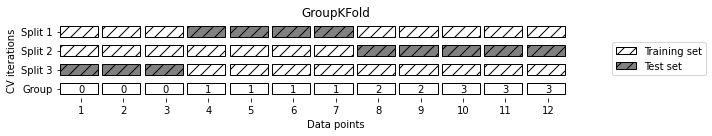

In [21]:
mglearn.plots.plot_group_kfold()

In [22]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
logreg = LogisticRegression(max_iter=1000)

In [23]:
from sklearn.model_selection import RepeatedStratifiedKFold

rskfold = RepeatedStratifiedKFold(random_state=42)
scores = cross_val_score(logreg, iris.data, iris.target, cv=rskfold)

print('cross validation score: \n', scores)
print('cross validation mean score: {:.3f}'.format(scores.mean()))

cross validation score: 
 [1.         0.96666667 0.93333333 1.         0.93333333 0.96666667
 0.96666667 0.93333333 1.         0.96666667 0.93333333 1.
 1.         0.96666667 0.96666667 0.9        1.         1.
 0.93333333 0.96666667 0.93333333 0.96666667 0.96666667 1.
 0.96666667 1.         0.96666667 0.96666667 0.9        1.
 0.96666667 0.96666667 0.96666667 0.96666667 0.93333333 0.96666667
 0.96666667 1.         1.         0.9        0.96666667 1.
 0.9        0.96666667 0.96666667 0.9        0.96666667 0.96666667
 1.         0.96666667]
cross validation mean score: 0.965


In [25]:
# 간단한 그리드 서치 구현
from sklearn.svm import SVC
x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)
print('train set size:{} test set size:{}'.format(x_train.shape[0], x_test.shape[0]))

best_score = 0

for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        # 매개변수의 각 조합에 대해 SVC를 훈련시킵니다
        svm = SVC(gamma=gamma, C=C)
        svm.fit(x_train, y_train)
        # 테스트 세트로 SVC를 평가합니다
        score = svm.score(x_test, y_test)
        # 점수가 더 높으면 매개변수와 함께 기록합니다
        if score > best_score:
            best_score = score
            best_parameters = {'C':C, 'gamma':gamma}
            
print('best score: {:.2f}'.format(best_score))
print('best parmeter:', best_parameters)

train set size:112 test set size:38
best score: 0.97
best parmeter: {'C': 100, 'gamma': 0.001}


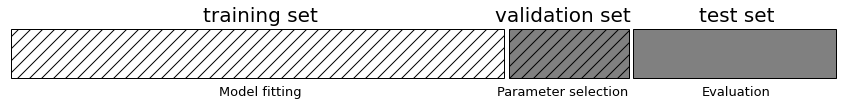

In [26]:
mglearn.plots.plot_threefold_split()

In [27]:
from sklearn.svm import SVC
# 데이터를 훈련+검증 세트 그리고 테스트 세트로 분할
x_trainval, x_test, y_trainval, y_test = train_test_split(iris.data, iris.target, random_state=0)
# 훈련+검증 세트를 훈련 세트와 검증 세트로 분할
x_train, x_vaild, y_train, y_vaild = train_test_split(x_trainval, y_trainval, random_state=1)
print('train set size:{} vaild set size:{} test set size:{}\n'.format(x_train.shape[0], x_vaild.shape[0], x_test.shape[0]))

best_score = 0

for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        # 매개변수의 각 조합에 대해 SVC를 훈련시킵니다
        svm = SVC(gamma=gamma, C=C)
        svm.fit(x_train, y_train)
        # 검증 세트로 SVC를 평가합니다
        score = svm.score(x_vaild, y_vaild)
        # 점수가 더 높으면 매개변수와 함께 기록합니다
        if score > best_score:
            best_score = score
            best_parameters = {'C':C, 'gamma':gamma}
            
# 훈련 세트와 검증 세트를 합쳐 모델을 다시 만든 후 테스트 세트를 사용해 평가합니다
svm = SVC(**best_parameters)
svm.fit(x_trainval, y_trainval)
test_score = svm.score(x_test, y_test)
print('vaild set best score: {:.2f}'.format(best_score))
print('best parameter:', best_parameters)
print('best parameter test set score: {:.2f}'.format(test_score))

train set size:84 vaild set size:28 test set size:38

vaild set best score: 0.96
best parameter: {'C': 10, 'gamma': 0.001}
best parameter test set score: 0.92


In [28]:
for gamma in [0.001,0.01,0.1,1,10,100]:
    for C in [0.001,0.01,0.1,1,10,100]:
        # 매개변수의 각 조합에 대해 SVC를 훈련시킵니다
        svm = SVC(gamma=gamma, C=C)
        # 교차 검증을 적용합니다
        scores = cross_val_score(svm, x_trainval, y_trainval, cv=5)
        # 교차 검증 정확도의 평균을 계산합니다
        score = np.mean(scores)
        # 점수가 더 높으면 매개변수와 함께 기록합니다
        if score > best_score:
            best_score = score
            best_parameters = {'C':C, 'gamma':gamma}
            
# 훈련 세트와 검증 세트를 합쳐 모델을 다시 만듭니다
svm = SVC(**best_parameters)
svm.fit(x_trainval, y_trainval)

SVC(C=10, gamma=0.1)

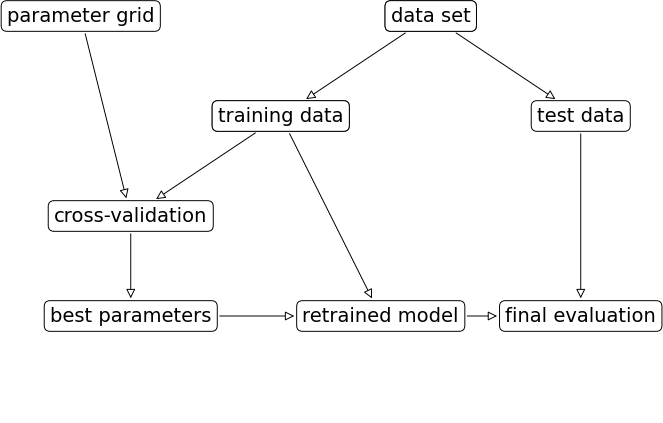

In [30]:
mglearn.plots.plot_grid_search_overview()

In [31]:
param_grid = {'C':[0.001,0.01,0.1,1,10,100],
              'gamma':[0.001,0.01,0.1,1,10,100]}
print('parameter grid:\n', param_grid)

parameter grid:
 {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}


In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
grid_search = GridSearchCV(SVC(), param_grid, cv=5, return_train_score=True)

In [33]:
x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)

In [34]:
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'gamma': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True)

In [35]:
print('test set score: {:.2f}'.format(grid_search.score(x_test, y_test)))

test set score: 0.97


In [36]:
print('best parameter:', grid_search.best_params_)
print('best cross vaild score: {:.2f}'.format(grid_search.best_score_))

best parameter: {'C': 10, 'gamma': 0.1}
best cross vaild score: 0.97


In [37]:
print('best estimator:\n', grid_search.best_estimator_)

best estimator:
 SVC(C=10, gamma=0.1)


In [38]:
pd.set_option('display.max_columns', None)
# DataFrame으로 변환합니다
results = pd.DataFrame(grid_search.cv_results_)
# 처음 다섯 개 행을 출력합니다
np.transpose(results.head())

,0,1,2,3,4
mean_fit_time,0.000685,0.000404,0.000807,0.001407,0.002157
std_fit_time,0.00137,0.000807,0.001613,0.002815,0.00312
mean_score_time,0.0,0.001597,0.0,0.000108,0.0
std_score_time,0.0,0.003195,0.0,0.000217,0.0
param_C,0.001,0.001,0.001,0.001,0.001
param_gamma,0.001,0.01,0.1,1,10
params,"{'C': 0.001, 'gamma': 0.001}","{'C': 0.001, 'gamma': 0.01}","{'C': 0.001, 'gamma': 0.1}","{'C': 0.001, 'gamma': 1}","{'C': 0.001, 'gamma': 10}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826
split1_test_score,0.347826,0.347826,0.347826,0.347826,0.347826
split2_test_score,0.363636,0.363636,0.363636,0.363636,0.363636


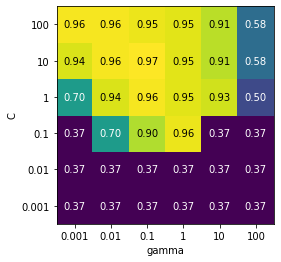

In [39]:
scores = np.array(results.mean_test_score).reshape(6,6)

# 교차 검증 평균 점수 히트맵 그래프
mglearn.tools.heatmap(scores, xlabel='gamma', xticklabels=param_grid['gamma'], 
                      ylabel='C', yticklabels=param_grid['C'], cmap='viridis')

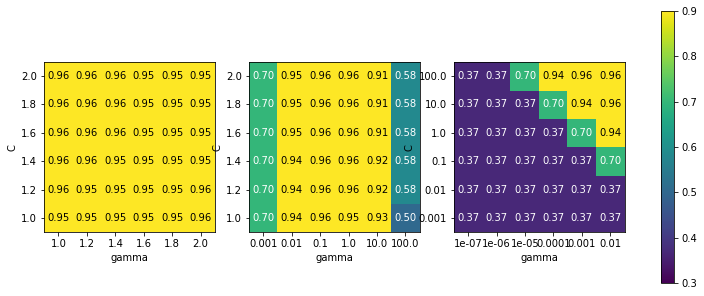

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(13,5))

param_grid_linear = {'C':np.linspace(1,2,6),
                     'gamma':np.linspace(1,2,6)}

param_grid_one_log = {'C':np.linspace(1,2,6),
                      'gamma':np.logspace(-3,2,6)}

param_grid_range = {'C':np.logspace(-3,2,6),
                    'gamma':np.logspace(-7,-2,6)}

for param_grid, ax in zip([param_grid_linear, param_grid_one_log, param_grid_range], axes):
    grid_search = GridSearchCV(SVC(), param_grid, cv=5)
    grid_search.fit(x_train, y_train)
    scores = grid_search.cv_results_['mean_test_score'].reshape(6,6)
    
    # 교차 검증 평균 점수의 히트맵 그래프
    scores_image = mglearn.tools.heatmap(scores, xlabel='gamma', xticklabels=param_grid['gamma'],
                                         ylabel='C', yticklabels=param_grid['C'], cmap='viridis', ax=ax, vmin=0.3, vmax=0.9)

plt.colorbar(scores_image, ax=axes.tolist())

In [41]:
param_grid = [{'kernel':['rbf'],
               'C': [0.001,0.01,0.1,1,10,100],
               'gamma':[0.001,0.01,0.1,1,10,100]},
              {'kernel':['linear'],
               'C':[0.001,0.01,0.1,1,10,100]}]
print('grid list:\n', param_grid)

grid list:
 [{'kernel': ['rbf'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10, 100]}, {'kernel': ['linear'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}]


In [42]:
grid_search = GridSearchCV(SVC(), param_grid, cv=5, return_train_score=True)
grid_search.fit(x_train, y_train)
print('best parameter:', grid_search.best_params_)
print('best score: {:.2f}'.format(grid_search.best_score_))

best parameter: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
best score: 0.97


In [43]:
results = pd.DataFrame(grid_search.cv_results_)
# 좀 더 나은 출력을 위해 결과를 전치시킵니다
results.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41
mean_fit_time,0.000342,0.00055,0.0004,0.000599,0.000535,0.0006,0.000373,0.000401,0.000399,0.000199,0.000399,0.000799,0.000304,0.000399,0.000827,0.000199,0.000398,0.000799,0.000598,0.000199,0.0,0.0,0.000574,0.000798,0.000399,0.0,0.000399,0.0,0.000598,0.000601,0.0006,0.000199,0.000398,0.0,0.000598,0.000399,0.0,0.000999,0.000199,0.000199,0.000404,0.000399
std_fit_time,0.000428,0.000458,0.00049,0.000489,0.000452,0.00049,0.000459,0.000491,0.000488,0.000398,0.000489,0.000399,0.000401,0.000489,0.000417,0.000399,0.000488,0.0004,0.000488,0.000397,0.0,0.0,0.000471,0.000399,0.000488,0.0,0.000488,0.0,0.000488,0.000491,0.00049,0.000399,0.000488,0.0,0.000489,0.000489,0.0,0.000003,0.000399,0.000397,0.000495,0.000488
mean_score_time,0.0002,0.000199,0.000199,0.000201,0.0,0.0,0.000199,0.000399,0.000199,0.000209,0.000399,0.000199,0.000199,0.000198,0.0,0.000399,0.000199,0.0002,0.0002,0.000199,0.0,0.0,0.000423,0.000199,0.000199,0.0,0.000199,0.000999,0.000399,0.000304,0.000398,0.000199,0.0,0.0,0.000199,0.000373,0.0,0.0,0.000199,0.000105,0.000199,0.000199
std_score_time,0.0004,0.000399,0.000399,0.000401,0.0,0.0,0.000399,0.000488,0.000399,0.000418,0.000488,0.000397,0.000399,0.000396,0.0,0.000488,0.000399,0.000399,0.000399,0.000398,0.0,0.0,0.00052,0.000399,0.000399,0.0,0.000399,0.000003,0.000489,0.000402,0.000488,0.000399,0.0,0.0,0.000398,0.000458,0.0,0.0,0.000399,0.00021,0.000399,0.000399
param_C,0.001,0.001,0.001,0.001,0.001,0.001,0.01,0.01,0.01,0.01,0.01,0.01,0.1,0.1,0.1,0.1,0.1,0.1,1,1,1,1,1,1,10,10,10,10,10,10,100,100,100,100,100,100,0.001,0.01,0.1,1,10,100
param_gamma,0.001,0.01,0.1,1,10,100,0.001,0.01,0.1,1,10,100,0.001,0.01,0.1,1,10,100,0.001,0.01,0.1,1,10,100,0.001,0.01,0.1,1,10,100,0.001,0.01,0.1,1,10,100,NaN,NaN,NaN,NaN,NaN,NaN
param_kernel,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,rbf,linear,linear,linear,linear,linear,linear
params,"{'C': 0.001, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.001, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.01, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 10, 'kernel': 'rbf'}","{'C': 0.1, 'gamma': 100, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 1, 'gamma': 1, 'kernel': 'rbf'}","{'C': 1, 'gamma': 10, 'kernel': 'rbf'}","{'C': 1, 'gamma': 100, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 10, 'gamma': 1, 'kernel': 'rbf'}","{'C': 10, 'gamma': 10, 'kernel': 'rbf'}","{'C': 10, 'gamma': 100, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}","{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 1, 'kernel': 'rbf'}","{'C': 100, 'gamma': 10, 'kernel': 'rbf'}","{'C': 100, 'gamma': 100, 'kernel': 'rbf'}","{'C': 0.001, 'kernel': 'linear'}","{'C': 0.01, 'kernel': 'linear'}","{'C': 0.1, 'kernel': 'linear'}","{'C': 1, 'kernel': 'linear'}","{'C': 10, 'kernel': 'linear'}","{'C': 100, 'kernel': 'linear'}"
split0_test_score,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.347826,0.695652,0.91304

In [44]:
param_grid = {'C':[0.001,0.01,0.1,1,10,100],
              'gamma':[0.001,0.01,0.1,1,10,100]}
scores = cross_val_score(GridSearchCV(SVC(), param_grid, cv=5), iris.data, iris.target, cv=5)
print('cross vaild score:', scores)
print('cross vaild mean score:', scores.mean())

cross vaild score: [0.96666667 1.         0.96666667 0.96666667 1.        ]
cross vaild mean score: 0.9800000000000001


In [45]:
def nested_cv(x, y, inner_cv, outer_cv, Classifier, parameter_grid):
    outer_scores = []
    # outer_cv의 분할을 순회하는 for 루프
    # (split 메소드는 훈련과 테스트 세트에 해당하는 인덱스를 반환합니다)
    for training_samples, test_samples in outer_cv.split(x, y):
        # 최적의 매개변수를 찾습니다
        best_params = {}
        best_score = -np.inf
        # 매개변수 그리드를 순회합니다
        for parameters in parameter_grid:
            # 안쪽 교차 검증의 점수를 기록합니다
            cv_scores = []
            # inner_cv의 분할을 순회하는 for 루프
            for inner_train, inner_test in inner_cv.split(x[training_samples], y[training_samples]):
                # 훈련 데이터와 주어진 매개변수로 분류기를 만듭니다
                clf = Classifier(**parameters)
                clf.fit(x[inner_train], y[inner_train])
                # 검증 세트로 평가합니다
                score = clf.score(x[inner_test], y[inner_test])
                cv_scores.append(score)
            # 안쪽 교차 검증의 평균 점수를 계산합니다
            mean_score = np.mean(cv_scores)
            if mean_score > best_score:
                # 점수가 더 높으면 매개변수와 함께 기록합니다
                best_score = mean_score
                best_params = parameters
        # 바깥쪽 훈련 데이터 전체를 사용해 분류기를 만듭니다
        clf = Classifier(**best_params)
        clf.fit(x[training_samples], y[training_samples])
        # 테스트 세트를 사용해 평가합니다
        outer_scores.append(clf.score(x[test_samples], y[test_samples]))
    return np.array(outer_scores)

In [46]:
from sklearn.model_selection import ParameterGrid, StratifiedKFold
scores = nested_cv(iris.data, iris.target, StratifiedKFold(5), StratifiedKFold(5), SVC, ParameterGrid(param_grid))
print('cross vaild score:', scores)

cross vaild score: [0.96666667 1.         0.96666667 0.96666667 1.        ]


In [47]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.fixes import loguniform

param_list = [{'kernel':['rbf'], 
               'C':loguniform(0.001,100),
               'gamma':loguniform(0.001,100)},
              {'kernel':['linear'],
               'C':loguniform(0.001,100)}]

In [48]:
rand_search = RandomizedSearchCV(SVC(), param_list, n_iter=20, random_state=42, n_jobs=-1)
rand_search.fit(x_train, y_train)
print('best param:', rand_search.best_params_)
print('best cross vaild score: {:.2f}'.format(rand_search.best_score_))

best param: {'C': 1.7965626423790642, 'kernel': 'linear'}
best cross vaild score: 0.97


In [49]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

param_grid = [{'kernel':['rbf'],
               'C': [0.001,0.01,0.1,1,10,100],
               'gamma':[0.001,0.01,0.1,1,10,100]},
              {'kernel':['linear'],
               'C':[0.001,0.01,0.1,1,10,100]}]
halv_search = HalvingGridSearchCV(SVC(), param_grid, verbose=1, random_state=42, n_jobs=-1)
halv_search.fit(x_train, y_train)
print()
print('best param:', halv_search.best_params_)
print('best score: {:.2f}'.format(halv_search.best_score_))

n_iterations: 2
n_required_iterations: 4
n_possible_iterations: 2
min_resources_: 30
max_resources_: 112
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 42
n_resources: 30
Fitting 5 folds for each of 42 candidates, totalling 210 fits
----------
iter: 1
n_candidates: 14
n_resources: 90
Fitting 5 folds for each of 14 candidates, totalling 70 fits

best param: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
best score: 0.97


In [50]:
print('source list:', halv_search.n_resources_)
print('candidator list:', halv_search.n_candidates_)

source list: [30, 90]
candidator list: [42, 14]


In [21]:
from sklearn.datasets import load_digits

digits = load_digits()
y = digits.target == 9

x_train, x_test, y_train, y_test = train_test_split(digits.data, y, random_state=0)

In [3]:
from sklearn.dummy import DummyClassifier
dummy_majority = DummyClassifier(strategy='most_frequent').fit(x_train, y_train)
pred_most_frequent = dummy_majority.predict(x_test)
print('predict label:', np.unique(pred_most_frequent))
print('test score: {:.2f}'.format(dummy_majority.score(x_test, y_test)))

predict label: [False]
test score: 0.90


In [4]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=2).fit(x_train, y_train)
pred_tree = tree.predict(x_test)
print('test score: {:.2f}'.format(tree.score(x_test, y_test)))

test score: 0.92


In [5]:
from sklearn.linear_model import LogisticRegression

dummy = DummyClassifier(strategy='stratified').fit(x_train, y_train)
pred_dummy = dummy.predict(x_test)
print('dummy score: {:.2f}'.format(dummy.score(x_test, y_test)))

logreg = LogisticRegression(C=0.1, max_iter=1000).fit(x_train, y_train)
pred_logreg = logreg.predict(x_test)
print('logreg score: {:.2f}'.format(logreg.score(x_test, y_test)))

dummy score: 0.82
logreg score: 0.98


In [6]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(y_test, pred_logreg)
print('con mtrx:\n', confusion)

con mtrx:
 [[402   1]
 [  6  41]]


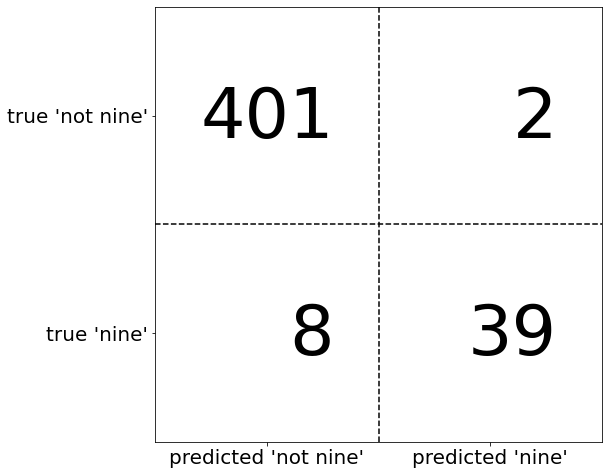

In [7]:
mglearn.plots.plot_confusion_matrix_illustration()

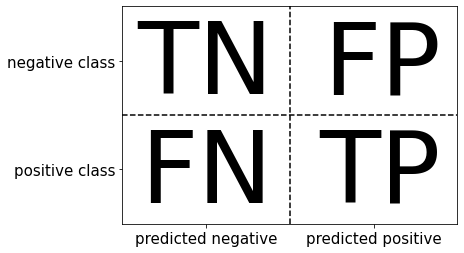

In [8]:
mglearn.plots.plot_binary_confusion_matrix()

In [9]:
print('dummy model:')
print(confusion_matrix(y_test, pred_most_frequent))
print('\nrandom dummy model:')
print(confusion_matrix(y_test, pred_dummy))
print('\ndecision tree:')
print(confusion_matrix(y_test, pred_tree))
print('\nlogit reg:')
print(confusion_matrix(y_test, pred_logreg))

dummy model:
[[403   0]
 [ 47   0]]

random dummy model:
[[372  31]
 [ 45   2]]

decision tree:
[[390  13]
 [ 24  23]]

logit reg:
[[402   1]
 [  6  41]]


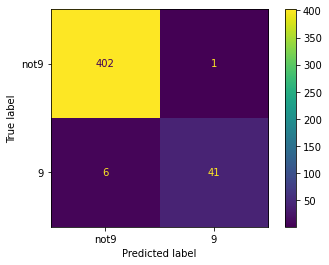

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(logreg, x_test, y_test, display_labels=['not9','9'])
plt.show()

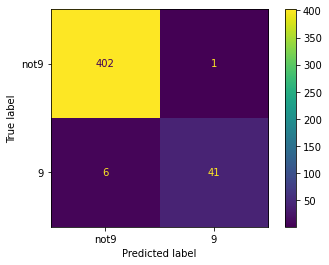

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, display_labels=['not9','9'])
plt.show()

In [10]:
from sklearn.metrics import f1_score
print('dummy model f1 score: {:.2f}'.format(f1_score(y_test, pred_most_frequent)))
print('random dummy model f1 score: {:.2f}'.format(f1_score(y_test, pred_dummy)))
print('tree model f1 score: {:.2f}'.format(f1_score(y_test, pred_tree)))
print('logreg f1 score: {:.2f}'.format(f1_score(y_test, pred_logreg)))

NameError: name 'pred_most_frequent' is not defined

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_most_frequent, target_names=['not9','9'], zero_division=0))

              precision    recall  f1-score   support

        not9       0.90      1.00      0.94       403
           9       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450



In [14]:
print(classification_report(y_test, pred_dummy, target_names=['not9','9']))

              precision    recall  f1-score   support

        not9       0.89      0.92      0.91       403
           9       0.06      0.04      0.05        47

    accuracy                           0.83       450
   macro avg       0.48      0.48      0.48       450
weighted avg       0.81      0.83      0.82       450



In [15]:
print(classification_report(y_test, pred_logreg, target_names=['not9','9']))

              precision    recall  f1-score   support

        not9       0.99      1.00      0.99       403
           9       0.98      0.87      0.92        47

    accuracy                           0.98       450
   macro avg       0.98      0.93      0.96       450
weighted avg       0.98      0.98      0.98       450



In [5]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
x, y = make_blobs(n_samples=(400, 50), cluster_std=[7.0, 2], random_state=22)
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
svc = SVC(gamma=.05).fit(x_train, y_train)

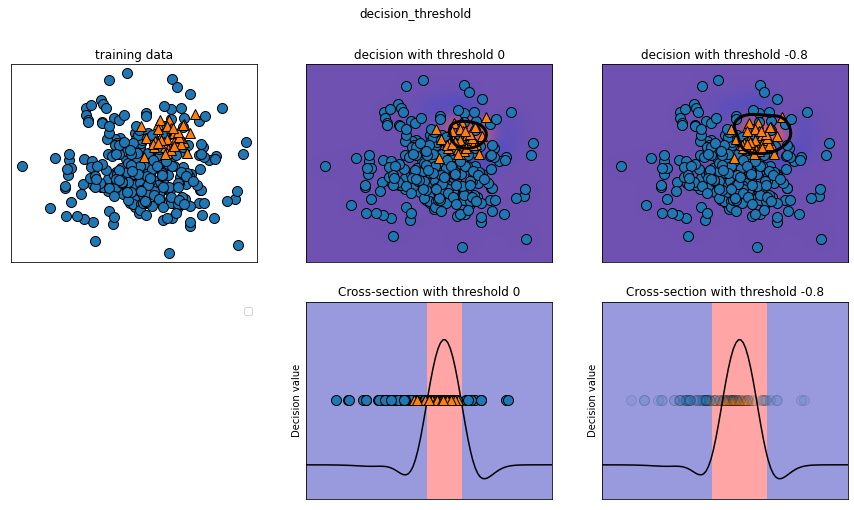

In [17]:
mglearn.plots.plot_decision_threshold()

In [18]:
print(classification_report(y_test, svc.predict(x_test)))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       104
           1       0.35      0.67      0.46         9

    accuracy                           0.88       113
   macro avg       0.66      0.78      0.70       113
weighted avg       0.92      0.88      0.89       113



In [19]:
y_pred_lower_threshold = svc.decision_function(x_test) > -.8

In [20]:
print(classification_report(y_test, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       104
           1       0.32      1.00      0.49         9

    accuracy                           0.83       113
   macro avg       0.66      0.91      0.69       113
weighted avg       0.95      0.83      0.87       113



In [6]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, svc.decision_function(x_test))

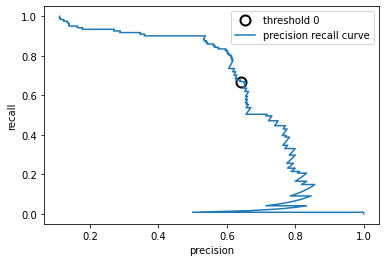

In [7]:
# 부드러운 곡선을 위해 데이터 포인트 수를 늘립니다
x, y = make_blobs(n_samples=(4000,500), cluster_std=[7.0,2], random_state=22)
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

svc = SVC(gamma=.05).fit(x_train, y_train)

precision, recall, thresholds = precision_recall_curve(y_test, svc.decision_function(x_test))
# 0에 가까운 임계값을 찾습니다
close_zero = np.argmin(np.abs(thresholds))
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10, label='threshold 0', fillstyle='none', c='k',mew=2)

plt.plot(precision, recall, label='precision recall curve')
plt.xlabel('precision')
plt.ylabel('recall')
plt.legend(loc='best')

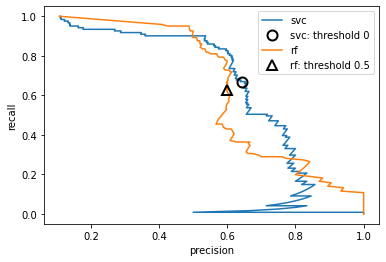

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=0, max_features=2)
rf.fit(x_train, y_train)

# RandomForestClassifier는 decision_function 대신 predict_porba를 제공합니다
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf.predict_proba(x_test)[:,1])

plt.plot(precision, recall, label='svc')

plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10, label='svc: threshold 0', fillstyle='none', c='k', mew=2)
plt.plot(precision_rf, recall_rf, label='rf')

close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(precision_rf[close_default_rf], recall_rf[close_default_rf], '^', c='k', 
         markersize=10, label='rf: threshold 0.5', fillstyle='none', mew=2)
plt.xlabel('precision')
plt.ylabel('recall')
plt.legend(loc='best')

In [11]:
from sklearn.metrics import f1_score
print('rf f1 score: {:.3f}'.format(f1_score(y_test, rf.predict(x_test))))
print('svc f1 score: {:.3f}'.format(f1_score(y_test, svc.predict(x_test))))

rf f1 score: 0.610
svc f1 score: 0.656


In [12]:
from sklearn.metrics import average_precision_score
ap_rf = average_precision_score(y_test, rf.predict_proba(x_test)[:,1])
ap_svc = average_precision_score(y_test, svc.decision_function(x_test))
print('rf avg pre: {:.3f}'.format(ap_rf))
print('svc avg pre: {:.3f}'.format(ap_svc))

rf avg pre: 0.660
svc avg pre: 0.666


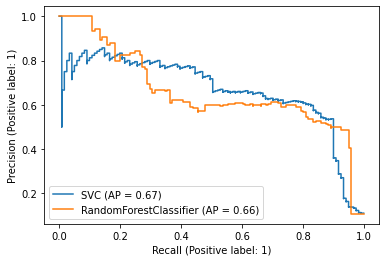

In [14]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots()
# SVC 곡선 그리기
PrecisionRecallDisplay.from_estimator(svc, x_test, y_test, ax=ax)
# 랜덤 포레스트 곡선 그리기
PrecisionRecallDisplay.from_estimator(rf, x_test, y_test, ax=ax)
plt.show()

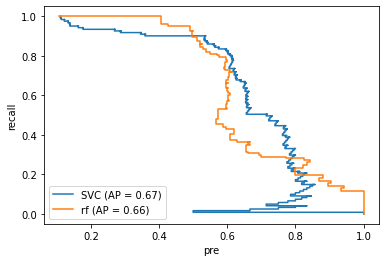

In [15]:
fig, ax = plt.subplots()
# SVC 곡선 그리기
disp = PrecisionRecallDisplay(precision=recall, recall=precision, average_precision=ap_svc, estimator_name='SVC')
disp.plot(ax=ax)
# 랜덤 포레스트 곡선 그리기
disp = PrecisionRecallDisplay(precision=recall_rf, recall=precision_rf, average_precision=ap_rf, estimator_name='rf')
disp.plot(ax=ax)
ax.set(xlabel='pre', ylabel='recall')
plt.show()

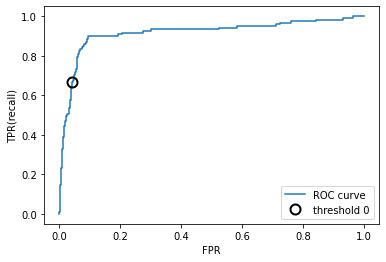

In [16]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, svc.decision_function(x_test))

plt.plot(fpr, tpr, label='ROC curve')
plt.xlabel('FPR')
plt.ylabel('TPR(recall)')
# 0 근처의 임계값을 찾습니다
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10, label='threshold 0', fillstyle='none', c='k', mew=2)
plt.legend(loc=4)

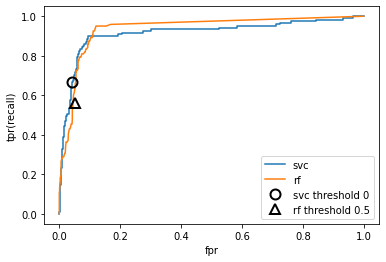

In [17]:
from sklearn.metrics import roc_curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf.predict_proba(x_test)[:,1])

plt.plot(fpr, tpr, label='svc')
plt.plot(fpr_rf, tpr_rf, label='rf')

plt.xlabel('fpr')
plt.ylabel('tpr(recall)')
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10, label='svc threshold 0', fillstyle='none', c='k', mew=2)
close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(fpr_rf[close_default_rf], tpr[close_default_rf], '^', 
         markersize=10, label='rf threshold 0.5', fillstyle='none', c='k', mew=2)
plt.legend(loc=4)

In [18]:
from sklearn.metrics import roc_auc_score
rf_auc = roc_auc_score(y_test, rf.predict_proba(x_test)[:,1])
svc_auc = roc_auc_score(y_test, svc.decision_function(x_test))
print('rf auc: {:.3f}'.format(rf_auc))
print('svc auc: {:.3f}'.format(svc_auc))

rf auc: 0.937
svc auc: 0.916


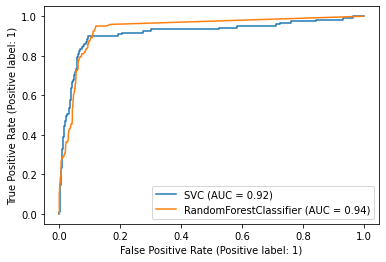

In [19]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots()
# SVC 곡선 그리기
RocCurveDisplay.from_estimator(svc, x_test, y_test, ax=ax)
# 랜덤 포레스트 곡선 그리기
RocCurveDisplay.from_estimator(rf, x_test, y_test, ax=ax)
plt.show()

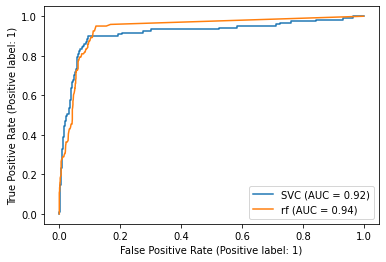

In [20]:
fig, ax = plt.subplots()
# SVC 곡선 그리기
RocCurveDisplay.from_predictions(y_test, svc.decision_function(x_test), name='SVC', ax=ax)
# 랜덤 포레스트 곡선 그리기
RocCurveDisplay.from_predictions(y_test, rf.predict_proba(x_test)[:,1], name='rf', ax=ax)
plt.show()

gamma = 1.00 accuracy = 0.90 auc = 0.50
gamma = 0.10 accuracy = 0.90 auc = 0.96
gamma = 0.01 accuracy = 0.90 auc = 1.00


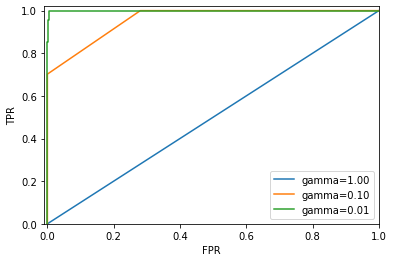

In [23]:
y = digits.target == 9

x_train, x_test, y_train, y_test = train_test_split(digits.data, y, random_state=0)

plt.figure()

for gamma in [1,0.1,0.01]:
    svc = SVC(gamma=gamma).fit(x_train, y_train)
    accuracy = svc.score(x_test, y_test)
    auc = roc_auc_score(y_test, svc.decision_function(x_test))
    fpr, tpr, _ = roc_curve(y_test, svc.decision_function(x_test))
    print('gamma = {:.2f} accuracy = {:.2f} auc = {:.2f}'.format(gamma, accuracy, auc))
    plt.plot(fpr, tpr, label='gamma={:.2f}'.format(gamma))
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.xlim(-0.01, 1)
plt.ylim(0, 1.02)
plt.legend(loc='best')

In [24]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=0)
lr = LogisticRegression(max_iter=5000).fit(x_train, y_train)
pred = lr.predict(x_test)
print('accuracy: {:.3f}'.format(accuracy_score(y_test, pred)))
print('confusion matrix:\n', confusion_matrix(y_test, pred))

accuracy: 0.953
confusion matrix:
 [[37  0  0  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  2  1]
 [ 0  0 41  3  0  0  0  0  0  0]
 [ 0  0  0 44  0  0  0  0  1  0]
 [ 0  0  0  0 37  0  0  1  0  0]
 [ 0  0  0  0  0 46  0  0  0  2]
 [ 0  1  0  0  0  0 51  0  0  0]
 [ 0  0  0  1  1  0  0 46  0  0]
 [ 0  3  1  0  0  0  1  0 43  0]
 [ 0  0  0  0  0  1  0  0  2 44]]


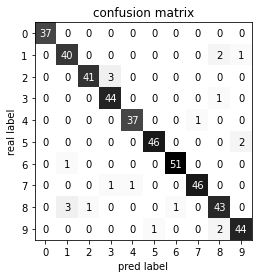

In [25]:
scores_image = mglearn.tools.heatmap(confusion_matrix(y_test, pred), 
                                     xlabel='pred label', ylabel='real label', xticklabels=digits.target_names,
                                     yticklabels=digits.target_names, cmap=plt.cm.gray_r, fmt='%d')
plt.title('confusion matrix')
plt.gca().invert_yaxis()

In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.91      0.93      0.92        43
           2       0.98      0.93      0.95        44
           3       0.92      0.98      0.95        45
           4       0.97      0.97      0.97        38
           5       0.98      0.96      0.97        48
           6       0.98      0.98      0.98        52
           7       0.98      0.96      0.97        48
           8       0.90      0.90      0.90        48
           9       0.94      0.94      0.94        47

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



In [27]:
print('micro avg f1 score: {:.3f}'.format(f1_score(y_test, pred, average='micro')))
print('macro avg f1 score: {:.3f}'.format(f1_score(y_test, pred, average='macro')))

micro avg f1 score: 0.953
macro avg f1 score: 0.954


In [30]:
from sklearn.model_selection import cross_val_score
# 분류의 기본 평가 지표는 정확도입니다
print('base eval score:', cross_val_score(SVC(), digits.data, digits.target == 9, cv=5))
# scoring = 'accuracy'의 결과는 같습니다
explicit_accuracy = cross_val_score(SVC(), digits.data, digits.target == 9, scoring='accuracy', cv=5)
print('accuracy score:', explicit_accuracy)
roc_auc = cross_val_score(SVC(), digits.data, digits.target == 9, scoring='roc_auc', cv=5)
print('avg precision score:', roc_auc)

base eval score: [0.975      0.99166667 1.         0.99442897 0.98050139]
accuracy score: [0.975      0.99166667 1.         0.99442897 0.98050139]
avg precision score: [0.99717078 0.99854252 1.         0.999828   0.98400413]


In [31]:
from sklearn.model_selection import cross_validate
res = cross_validate(SVC(), digits.data, digits.target == 9, scoring=['accuracy','roc_auc','recall_macro'], 
                     return_train_score=True, cv=5)
pd.DataFrame(res)

,fit_time,score_time,test_accuracy,train_accuracy,test_roc_auc,train_roc_auc,test_recall_macro,train_recall_macro
0,0.014755,0.023768,0.975000,0.994433,0.997171,0.998679,0.887346,0.972222
1,0.011218,0.019943,0.991667,0.995825,0.998543,0.999141,0.958333,0.982252
2,0.008041,0.022771,1.000000,0.995132,1.000000,0.998975,1.000000,0.978780
3,0.005913,0.020582,0.994429,0.995828,0.999828,0.998825,0.972222,0.982252
4,0.015711,0.010229,0.980501,0.996523,0.984004,0.999914,0.902778,0.985725


In [33]:
from sklearn.model_selection import GridSearchCV
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target == 9, random_state=0)

# 일부러 적절하지 않은 그리드를 만듭니다
param_grid = {'gamma': [0.0001, 0.01, 0.1, 1, 10]}
# 기본 정확도 측정 지표를 사용합니다
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=3)
grid.fit(x_train, y_train)
print('accuracy socre used grid search')
print('best parameter:', grid.best_params_)
print('best cross validation score: {:.3f}'.format(grid.best_score_))
print('test set avg precision: {:.3f}'.format(average_precision_score(y_test, grid.decision_function(x_test))))
print('test set accuracy: {:.3f}'.format(grid.score(x_test, y_test)))

accuracy socre used grid search
best parameter: {'gamma': 0.0001}
best cross validation score: 0.972
test set avg precision: 0.966
test set accuracy: 0.973


In [34]:
# 평균 정밀도 지표 사용
grid = GridSearchCV(SVC(), param_grid=param_grid, scoring='average_precision', cv=3)
grid.fit(x_train, y_train)
print('accuracy socre used grid search')
print('best parameter:', grid.best_params_)
print('best cross validation score: {:.3f}'.format(grid.best_score_))
print('test set avg precision: {:.3f}'.format(average_precision_score(y_test, grid.decision_function(x_test))))
print('test set accuracy: {:.3f}'.format(grid.score(x_test, y_test)))

accuracy socre used grid search
best parameter: {'gamma': 0.01}
best cross validation score: 0.985
test set avg precision: 0.996
test set accuracy: 0.996
